# ITM-390: AI-Based Threat Detection Pipeline

This notebook demonstrates an end-to-end Machine Learning pipeline for classifying network traffic as **Normal** or a **Threat** (Attack). It trains and compares five different classifiers that includes Logistic Regression, Random Forest, Decision Tree, KNN, and SVM and then tunes the best one via hyperparameter search and exports all artifacts for deployment in a Streamlit application.

## 1. Import Libraries
We begin by importing the necessary libraries. This includes `pandas` for data manipulation, `scikit-learn` for machine learning transformations and modeling, `imblearn` for handling class imbalances, and `seaborn` for visualization.

In [11]:
import glob
import os
import warnings

import joblib
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
BASE_DIR = os.path.dirname(os.path.abspath(''))
OUTPUT_DIR = os.path.join(BASE_DIR, "output")
ARTIFACTS_DIR = os.path.join(BASE_DIR, "artifacts")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

## 2. Define Helper Functions
These utility functions handle dataset downloading from Kaggle, locating the correct CSV file, detecting the target column, encoding the target into binary labels, and producing visualizations (class distribution, feature importance, confusion matrices, and model comparison bar charts).

In [12]:
def download_dataset():
    """Download the dataset from Kaggle using kagglehub."""
    dataset_id = "sampadab17/network-intrusion-detection"
    path = kagglehub.dataset_download(dataset_id)
    print(f"Downloaded: {dataset_id}")
    return dataset_id, path


def pick_labeled_csv(csv_files):
    """Scan CSVs and return the one that contains a known label column."""
    candidate_names = {"label", "class", "attack", "attack_cat", "target"}
    for csv_path in csv_files:
        try:
            head = pd.read_csv(csv_path, nrows=200)
        except Exception:
            continue
        head.columns = [str(col).strip().lower() for col in head.columns]
        if any(col in candidate_names for col in head.columns):
            return csv_path
    return csv_files[0]


def detect_target_column(df):
    """Return the name of the target column, or fall back to the last column."""
    candidates = ["label", "class", "attack", "attack_cat", "target"]
    for name in candidates:
        if name in df.columns:
            return name
    return df.columns[-1]


def encode_target(y_series):
    """Convert string labels (e.g. 'normal', 'anomaly') into binary 0/1."""
    y_str = y_series.astype(str).str.strip().str.lower()
    return y_str.apply(lambda v: 0 if v in {"normal", "benign", "0"} else 1)


def save_class_distribution(y, file_path):
    """Bar chart of class counts."""
    counts = y.value_counts().sort_index()
    labels = ["Normal (0)", "Attack (1)"]
    plt.figure(figsize=(6, 4))
    bars = plt.bar(labels, counts.values, color=["#4caf50", "#f44336"])
    plt.title("Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Count")
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, h, f"{int(h)}", ha="center", va="bottom")
    plt.tight_layout()
    plt.savefig(file_path, dpi=200)
    plt.show()


def save_confusion_matrix(y_true, y_pred, model_name, file_path):
    """Heatmap confusion matrix for one model."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(file_path, dpi=200)
    plt.show()
    return cm


def save_model_comparison(summary_df, file_path):
    """Grouped bar chart comparing all models."""
    metrics = ["Accuracy", "Precision", "Recall", "F1"]
    x = np.arange(len(summary_df["Model"]))
    width = 0.18
    plt.figure(figsize=(12, 6))
    for i, metric in enumerate(metrics):
        plt.bar(x + i * width, summary_df[metric], width=width, label=metric)
    plt.title("Model Metrics Comparison")
    plt.xlabel("Model")
    plt.ylabel("Score")
    plt.xticks(x + width * 1.5, summary_df["Model"], rotation=15)
    plt.ylim(0, 1.05)
    plt.legend()
    plt.tight_layout()
    plt.savefig(file_path, dpi=200)
    plt.show()

## 3. Download and Load Data
We download the dataset, locate the training CSV, load it into a DataFrame, and perform initial cleaning by dropping rows with `NaN` or infinite values and removing columns that contain only a single constant value (zero predictive power).

=== STEP 1/2: Download and load data ===
Downloaded: sampadab17/network-intrusion-detection
Using CSV file: C:\Users\Tommy\.cache\kagglehub\datasets\sampadab17\network-intrusion-detection\versions\1\Train_data.csv
Dataset shape: (25192, 42)

Detected target column: class
Dropped constant columns: ['num_outbound_cmds', 'is_host_login']

Encoded class counts:
 class
0    13449
1    11743
Name: count, dtype: int64


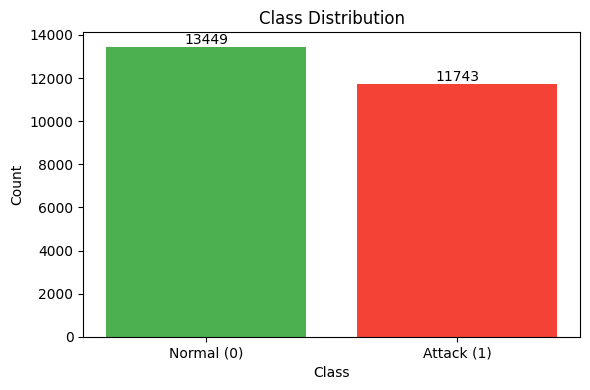

In [13]:
print("=== STEP 1/2: Download and load data ===")
dataset_name, dataset_path = download_dataset()
csv_files = glob.glob(os.path.join(dataset_path, "**", "*.csv"), recursive=True)
csv_path = pick_labeled_csv(csv_files)
print("Using CSV file:", csv_path)

df = pd.read_csv(csv_path)
df.columns = [str(col).strip().lower() for col in df.columns]
print("Dataset shape:", df.shape)

target_col = detect_target_column(df)
print("\nDetected target column:", target_col)

# Clean
df = df.replace([np.inf, -np.inf], np.nan).dropna(axis=0).reset_index(drop=True)
nunique = df.nunique(dropna=False)
constant_cols = [c for c in df.columns if c != target_col and nunique[c] <= 1]
if constant_cols:
    df = df.drop(columns=constant_cols)
    print("Dropped constant columns:", constant_cols)

y = encode_target(df[target_col])
X = df.drop(columns=[target_col])
print("\nEncoded class counts:\n", y.value_counts())

save_class_distribution(y, os.path.join(OUTPUT_DIR, "class_distribution.png"))

## 4. Train/Test Split & Leakage Prevention
To prevent data leakage, we split the data into Training and Testing sets *before* applying any transformations like scaling or encoding.

We also identify categorical columns (`protocol_type`, `service`, `flag`), extract their unique options for the Streamlit UI dropdown menus, and save them.

In [14]:
# Identify categorical columns and save options for the UI
cat_cols = ["protocol_type", "service", "flag"]
cat_cols = [c for c in cat_cols if c in X.columns]

categorical_info = {col: X[col].unique().tolist() for col in cat_cols}
joblib.dump(categorical_info, os.path.join(ARTIFACTS_DIR, "categorical_info.pkl"))

# Split FIRST — no data leakage
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Temporarily ordinal-encode ONLY training data for feature selection
X_train_oe = X_train_raw.copy()
if cat_cols:
    oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train_oe[cat_cols] = oe.fit_transform(X_train_oe[cat_cols])

## 5. Feature Selection
Using all 40+ features can lead to overfitting and slow deployment. We train a quick Random Forest on the ordinal-encoded training data to rank features by importance, then select only the **top 15**.

=== STEP 4: Feature selection ===


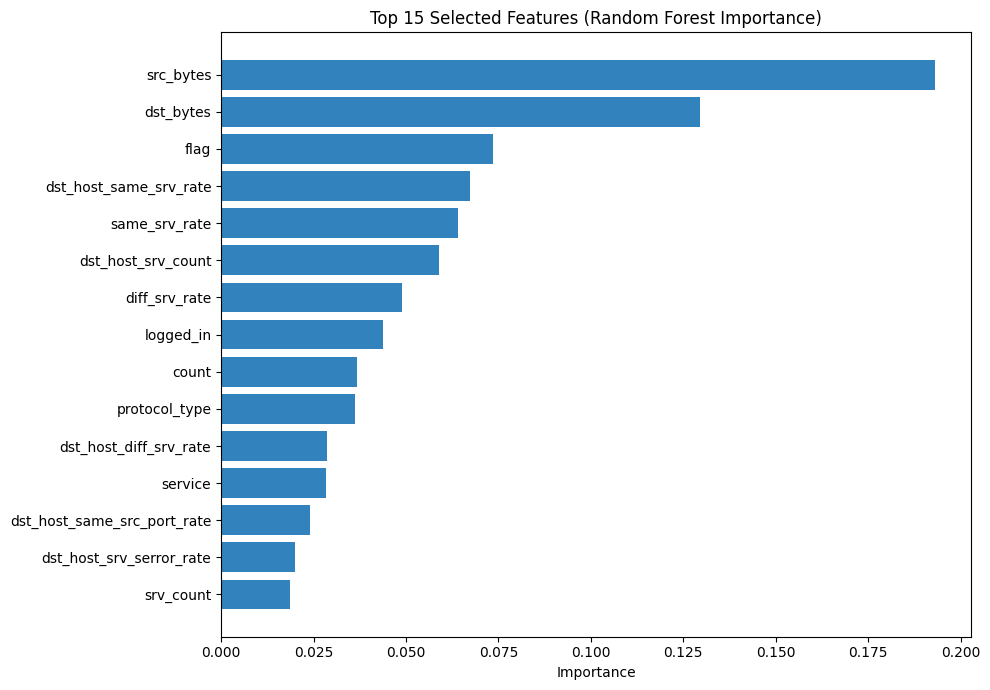

Selected features (top 15): ['srv_count', 'dst_host_srv_serror_rate', 'dst_host_same_src_port_rate', 'service', 'dst_host_diff_srv_rate', 'protocol_type', 'count', 'logged_in', 'diff_srv_rate', 'dst_host_srv_count', 'same_srv_rate', 'dst_host_same_srv_rate', 'flag', 'dst_bytes', 'src_bytes']


In [15]:
print("=== STEP 4: Feature selection ===")
selector_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
selector_model.fit(X_train_oe, y_train)

k = min(15, X_train_oe.shape[1])
importances = selector_model.feature_importances_
top_idx = np.argsort(importances)[-k:]

selected_features = [str(c) for c in X_train_oe.columns[top_idx]]
feature_scores = importances[top_idx]

# Plot
order = np.argsort(feature_scores)
plt.figure(figsize=(10, 7))
plt.barh(np.array(selected_features)[order], feature_scores[order], color="#3182bd")
plt.title("Top 15 Selected Features (Random Forest Importance)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_importance.png"), dpi=200)
plt.show()

print("Selected features (top 15):", selected_features)

## 6. Build ColumnTransformer & SMOTE Balancing
Now that we have our top 15 features, we build a Scikit-Learn `ColumnTransformer` that:
1. Applies `StandardScaler` to numerical columns.
2. Applies `OneHotEncoder` to categorical columns (`protocol_type`, `service`, `flag`).

We also use **SMOTE** (Synthetic Minority Over-sampling Technique) to balance the classes if the minority class represents less than 20% of the training data.

In [16]:
sel_cat_cols = [c for c in selected_features if c in cat_cols]
sel_num_cols = [c for c in selected_features if c not in cat_cols]

deploy_scaler = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), sel_num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), sel_cat_cols),
    ]
)

X_train_selected = X_train_raw[selected_features]
X_test_selected = X_test_raw[selected_features]

X_train_scaled = pd.DataFrame(
    deploy_scaler.fit_transform(X_train_selected), index=X_train_raw.index
)
X_test_scaled = pd.DataFrame(
    deploy_scaler.transform(X_test_selected), index=X_test_raw.index
)

# SMOTE if needed
class_ratio = y_train.value_counts(normalize=True)
minority_ratio = class_ratio.min()

if minority_ratio < 0.20:
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)
    print(f"SMOTE applied. Minority ratio before: {minority_ratio:.2%}")
else:
    X_train_balanced, y_train_balanced = X_train_scaled, y_train
    print(f"SMOTE not required. Minority ratio: {minority_ratio:.2%}")

X_train_selected = X_train_balanced
X_test_selected = X_test_scaled

SMOTE not required. Minority ratio: 46.61%


## 7. Train & Compare All Models
We train five different classifiers on the same processed training set and evaluate each against the held-out test set. This lets us objectively pick the best algorithm for our specific dataset.

**Models:** Logistic Regression, Random Forest, Decision Tree, KNN, SVM

=== STEP 5/6: Model training and evaluation ===


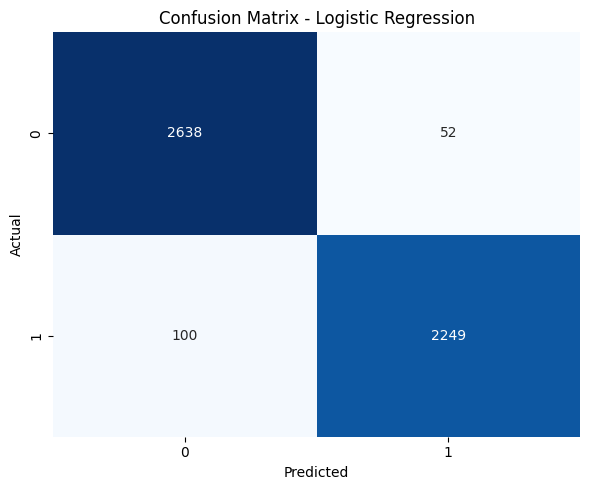

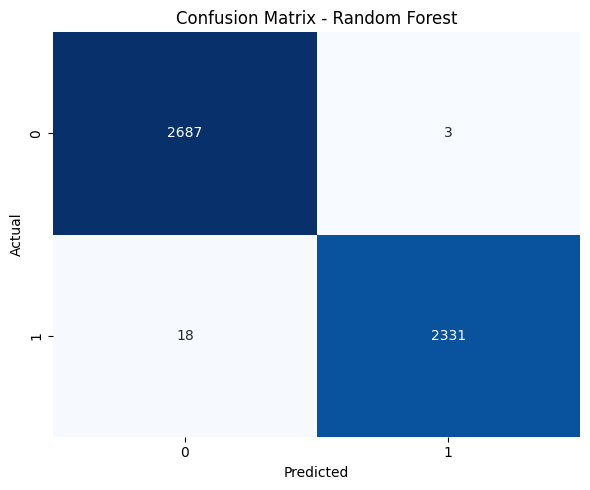

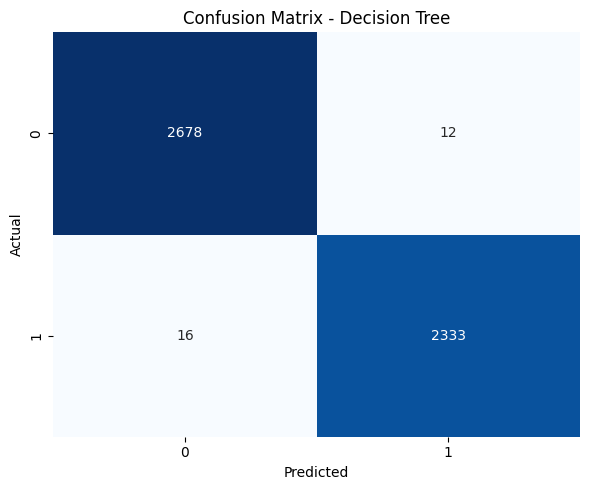

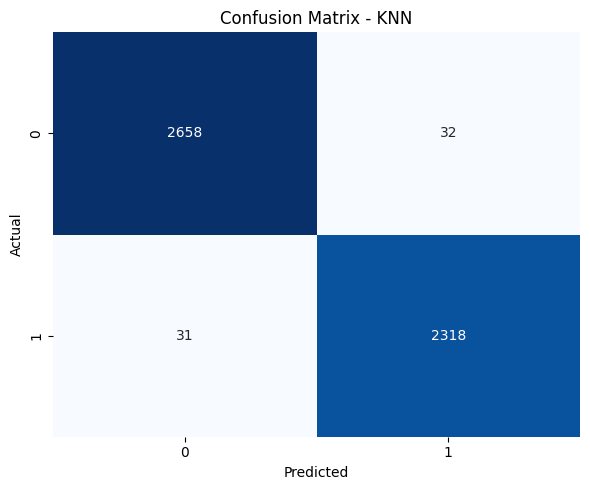

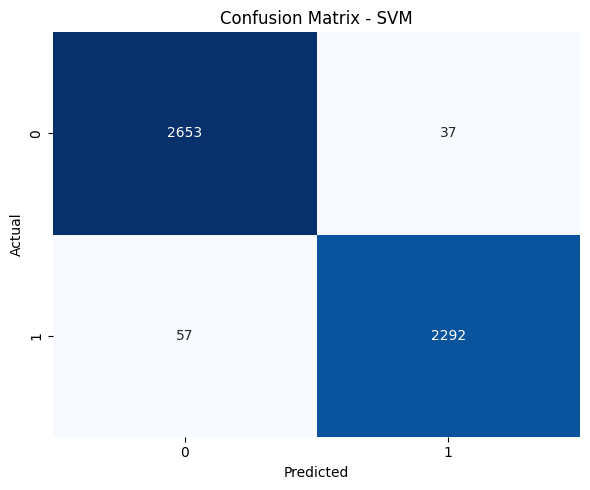

,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.995833,0.998715,0.992337,0.995516
1,Decision Tree,0.994443,0.994883,0.993189,0.994035
2,KNN,0.987498,0.986383,0.986803,0.986593
3,SVM,0.981346,0.984113,0.975734,0.979906
4,Logistic Regression,0.969835,0.977401,0.957429,0.967312


In [17]:
print("=== STEP 5/6: Model training and evaluation ===")

# Define all five models
train_size = len(X_train_selected)
use_linear_svc = train_size > 100000

if use_linear_svc:
    svm_model = LinearSVC(random_state=RANDOM_STATE)
    svm_label = "LinearSVC"
else:
    svm_model = SVC(kernel="rbf", random_state=RANDOM_STATE, probability=True)
    svm_label = "SVM"

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    svm_label: svm_model,
}

# Train and evaluate each model
results = []
reports = {}
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_selected, y_train_balanced)
    y_pred = model.predict(X_test_selected)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
    })
    reports[name] = classification_report(y_test, y_pred, digits=4)

    cm_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_{name.lower().replace(' ', '_')}.png")
    save_confusion_matrix(y_test, y_pred, name, cm_path)
    fitted_models[name] = model

summary_df = pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)
summary_df

## 8. Classification Reports
Print the detailed precision/recall/F1 breakdown for each of the five models.


Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0     0.9635    0.9807    0.9720      2690
           1     0.9774    0.9574    0.9673      2349

    accuracy                         0.9698      5039
   macro avg     0.9704    0.9690    0.9697      5039
weighted avg     0.9700    0.9698    0.9698      5039


Classification Report - Random Forest
              precision    recall  f1-score   support

           0     0.9933    0.9989    0.9961      2690
           1     0.9987    0.9923    0.9955      2349

    accuracy                         0.9958      5039
   macro avg     0.9960    0.9956    0.9958      5039
weighted avg     0.9958    0.9958    0.9958      5039


Classification Report - Decision Tree
              precision    recall  f1-score   support

           0     0.9941    0.9955    0.9948      2690
           1     0.9949    0.9932    0.9940      2349

    accuracy                         0.9944      5039
   ma

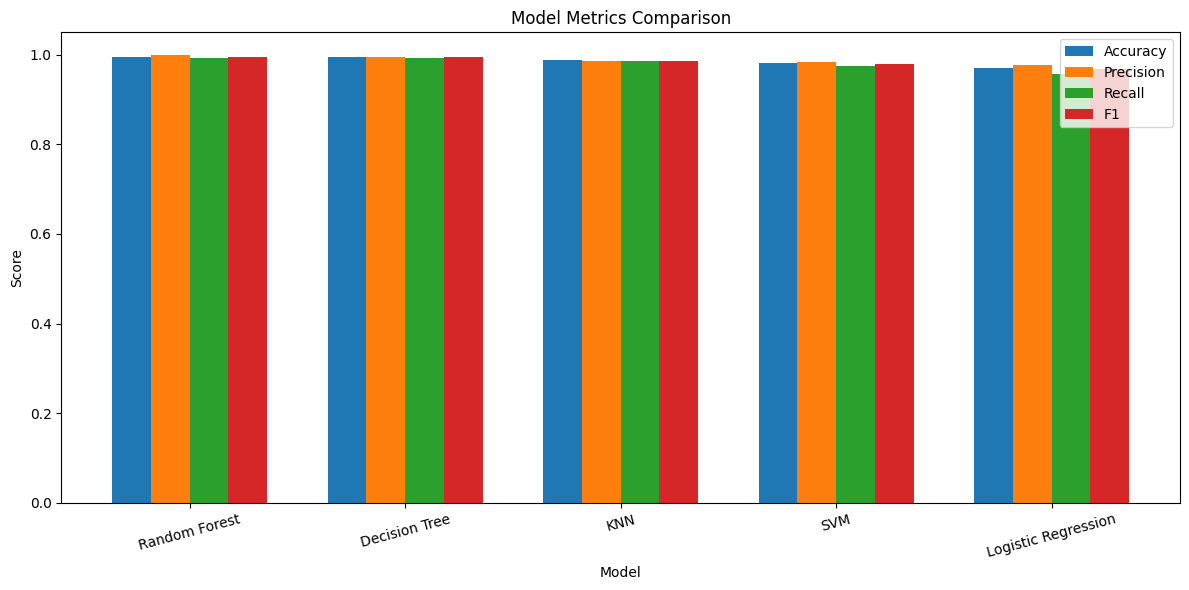


Best base model by F1: Random Forest


In [18]:
for name, report in reports.items():
    print(f"\nClassification Report - {name}")
    print(report)

save_model_comparison(summary_df, os.path.join(OUTPUT_DIR, "model_comparison.png"))

best_model_name = summary_df.iloc[0]["Model"]
best_base_model = fitted_models[best_model_name]
print(f"\nBest base model by F1: {best_model_name}")

## 9. Hyperparameter Tuning (Best Model)
We take the best-performing model from the comparison and use `RandomizedSearchCV` to find the optimal hyperparameters via 3-fold cross-validation. This fine-tunes the model for maximum F1-Score.

=== STEP 7: Hyperparameter tuning ===
Best params: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': None}

Tuned model report:
              precision    recall  f1-score   support

           0     0.9933    0.9989    0.9961      2690
           1     0.9987    0.9923    0.9955      2349

    accuracy                         0.9958      5039
   macro avg     0.9960    0.9956    0.9958      5039
weighted avg     0.9958    0.9958    0.9958      5039



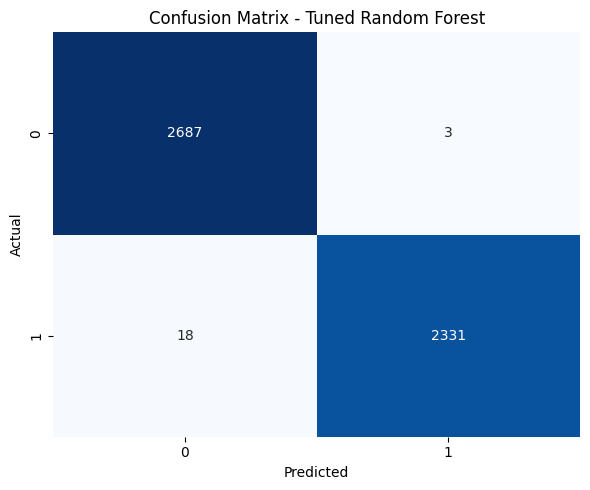

array([[2687,    3],
       [  18, 2331]])

In [19]:
print("=== STEP 7: Hyperparameter tuning ===")

tuning_spaces = {
    "Logistic Regression": {"C": [0.01, 0.1, 1, 10], "solver": ["lbfgs", "liblinear"]},
    "Random Forest": {"n_estimators": [50, 100, 200], "max_depth": [None, 10, 20], "min_samples_split": [2, 5]},
    "Decision Tree": {"max_depth": [None, 10, 20, 30], "min_samples_split": [2, 5, 10], "criterion": ["gini", "entropy"]},
    "KNN": {"n_neighbors": [3, 5, 7, 9], "weights": ["uniform", "distance"], "metric": ["euclidean", "manhattan"]},
    "SVM": {"C": [0.1, 1, 10], "gamma": ["scale", "auto", 0.01, 0.1], "kernel": ["rbf"]},
    "LinearSVC": {"C": [0.01, 0.1, 1, 10], "loss": ["hinge", "squared_hinge"]},
}

param_dist = tuning_spaces.get(best_model_name, {})
tuned_model = best_base_model
best_params = {}

if param_dist:
    search = RandomizedSearchCV(
        estimator=best_base_model,
        param_distributions=param_dist,
        n_iter=min(10, max(1, np.prod([len(v) for v in param_dist.values()]))),
        cv=3,
        scoring="f1",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    search.fit(X_train_selected, y_train_balanced)
    tuned_model = search.best_estimator_
    best_params = search.best_params_

tuned_model.fit(X_train_selected, y_train_balanced)
y_tuned_pred = tuned_model.predict(X_test_selected)

tuned_acc = accuracy_score(y_test, y_tuned_pred)
tuned_prec = precision_score(y_test, y_tuned_pred, zero_division=0)
tuned_rec = recall_score(y_test, y_tuned_pred, zero_division=0)
tuned_f1 = f1_score(y_test, y_tuned_pred, zero_division=0)

print("Best params:", best_params)
print("\nTuned model report:")
print(classification_report(y_test, y_tuned_pred, digits=4))

# Confusion matrix for the tuned model
save_confusion_matrix(y_test, y_tuned_pred, f"Tuned {best_model_name}",
                      os.path.join(OUTPUT_DIR, "confusion_matrix_best.png"))

## 10. Save Artifacts for Deployment
We export the tuned model, the fitted ColumnTransformer, the feature list, and the final metrics so that `app.py` (Streamlit dashboard) can load and use them directly.

In [20]:
joblib.dump(tuned_model, os.path.join(ARTIFACTS_DIR, "best_model.pkl"))
joblib.dump(deploy_scaler, os.path.join(ARTIFACTS_DIR, "scaler.pkl"))
joblib.dump(selected_features, os.path.join(ARTIFACTS_DIR, "feature_names.pkl"))
joblib.dump({
    "Accuracy": f"{tuned_acc:.2%}",
    "Precision": f"{tuned_prec:.2%}",
    "Recall": f"{tuned_rec:.2%}",
    "F1-Score": f"{tuned_f1:.2%}",
}, os.path.join(ARTIFACTS_DIR, "metrics.pkl"))

print("All artifacts saved!")
print(f"\nFinal Tuned {best_model_name} Performance:")
print(f"  Accuracy:  {tuned_acc:.1%}")
print(f"  Precision: {tuned_prec:.1%}")
print(f"  Recall:    {tuned_rec:.1%}")
print(f"  F1-Score:  {tuned_f1:.1%}")

All artifacts saved!

Final Tuned Random Forest Performance:
  Accuracy:  99.6%
  Precision: 99.9%
  Recall:    99.2%
  F1-Score:  99.6%
